# ISIC 2018 Dataset Exploration

このノートブックでは ISIC 2018 皮膚病変画像フォルダの構造とサンプル画像を確認します。

- 画像ルート: `/mnt/data1/Public/MedImages/ISIC2018_ImageFolder`
- 目的: データ枚数・サブフォルダ構成と代表的な画像を16枚表示し、サイズ分布の一端を把握する
- 注意: 医療画像なので極端なランダム変換は行わず、生画像の確認を主に行います。

In [1]:
# ライブラリ読み込みとパス定義
import os
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

DATA_ROOT = Path('/mnt/data1/Public/MedImages/CellData/chest_xray')
print('Root exists:', DATA_ROOT.exists())
print('Root path:', DATA_ROOT)

# 対象拡張子
EXTS = ("jpg", "jpeg", "png", "tif", "tiff", "bmp", "webp")

Root exists: True
Root path: /mnt/data1/Public/MedImages/CellData/chest_xray


In [2]:
# サブフォルダ列挙と画像件数集計
if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Directory not found: {DATA_ROOT}")

subdirs = [d for d in DATA_ROOT.iterdir() if d.is_dir()]
print(f"サブフォルダ数: {len(subdirs)}")
for d in subdirs:
    print('-', d.name)

# 件数集計
counts = {}
for d in subdirs:
    total = 0
    for ext in EXTS:
        total += len(list(d.rglob(f"*.{ext}")))
    counts[d.name] = total

print("\nフォルダ別画像枚数:")
for k,v in counts.items():
    print(f"  {k}: {v}")

サブフォルダ数: 2
- train
- test

フォルダ別画像枚数:
  train: 5232
  test: 624


In [3]:
# 画像パスを再帰的に収集し、16枚サンプル抽出
image_paths = []
for ext in EXTS:
    image_paths.extend([str(p) for p in DATA_ROOT.rglob(f"*.{ext}") if p.is_file()])

image_paths = sorted(list(set(image_paths)))
print(f"合計画像数: {len(image_paths)}")

if len(image_paths) >= 16:
    sample_paths = random.sample(image_paths, 16)
else:
    sample_paths = image_paths[:16]
    print(f"警告: 画像が16枚未満です ({len(image_paths)}枚)")

# 参考: 最初の数件のパスを表示
for i, p in enumerate(sample_paths[:5], 1):
    print(f"{i}. {p}")

合計画像数: 5856
1. /mnt/data1/Public/MedImages/CellData/chest_xray/test/NORMAL/NORMAL-4921478-0001.jpeg
2. /mnt/data1/Public/MedImages/CellData/chest_xray/train/PNEUMONIA/VIRUS-3974793-0002.jpeg
3. /mnt/data1/Public/MedImages/CellData/chest_xray/train/PNEUMONIA/VIRUS-1727027-0001.jpeg
4. /mnt/data1/Public/MedImages/CellData/chest_xray/train/PNEUMONIA/BACTERIA-9934736-0002.jpeg
5. /mnt/data1/Public/MedImages/CellData/chest_xray/test/PNEUMONIA/VIRUS-9039335-0001.jpeg


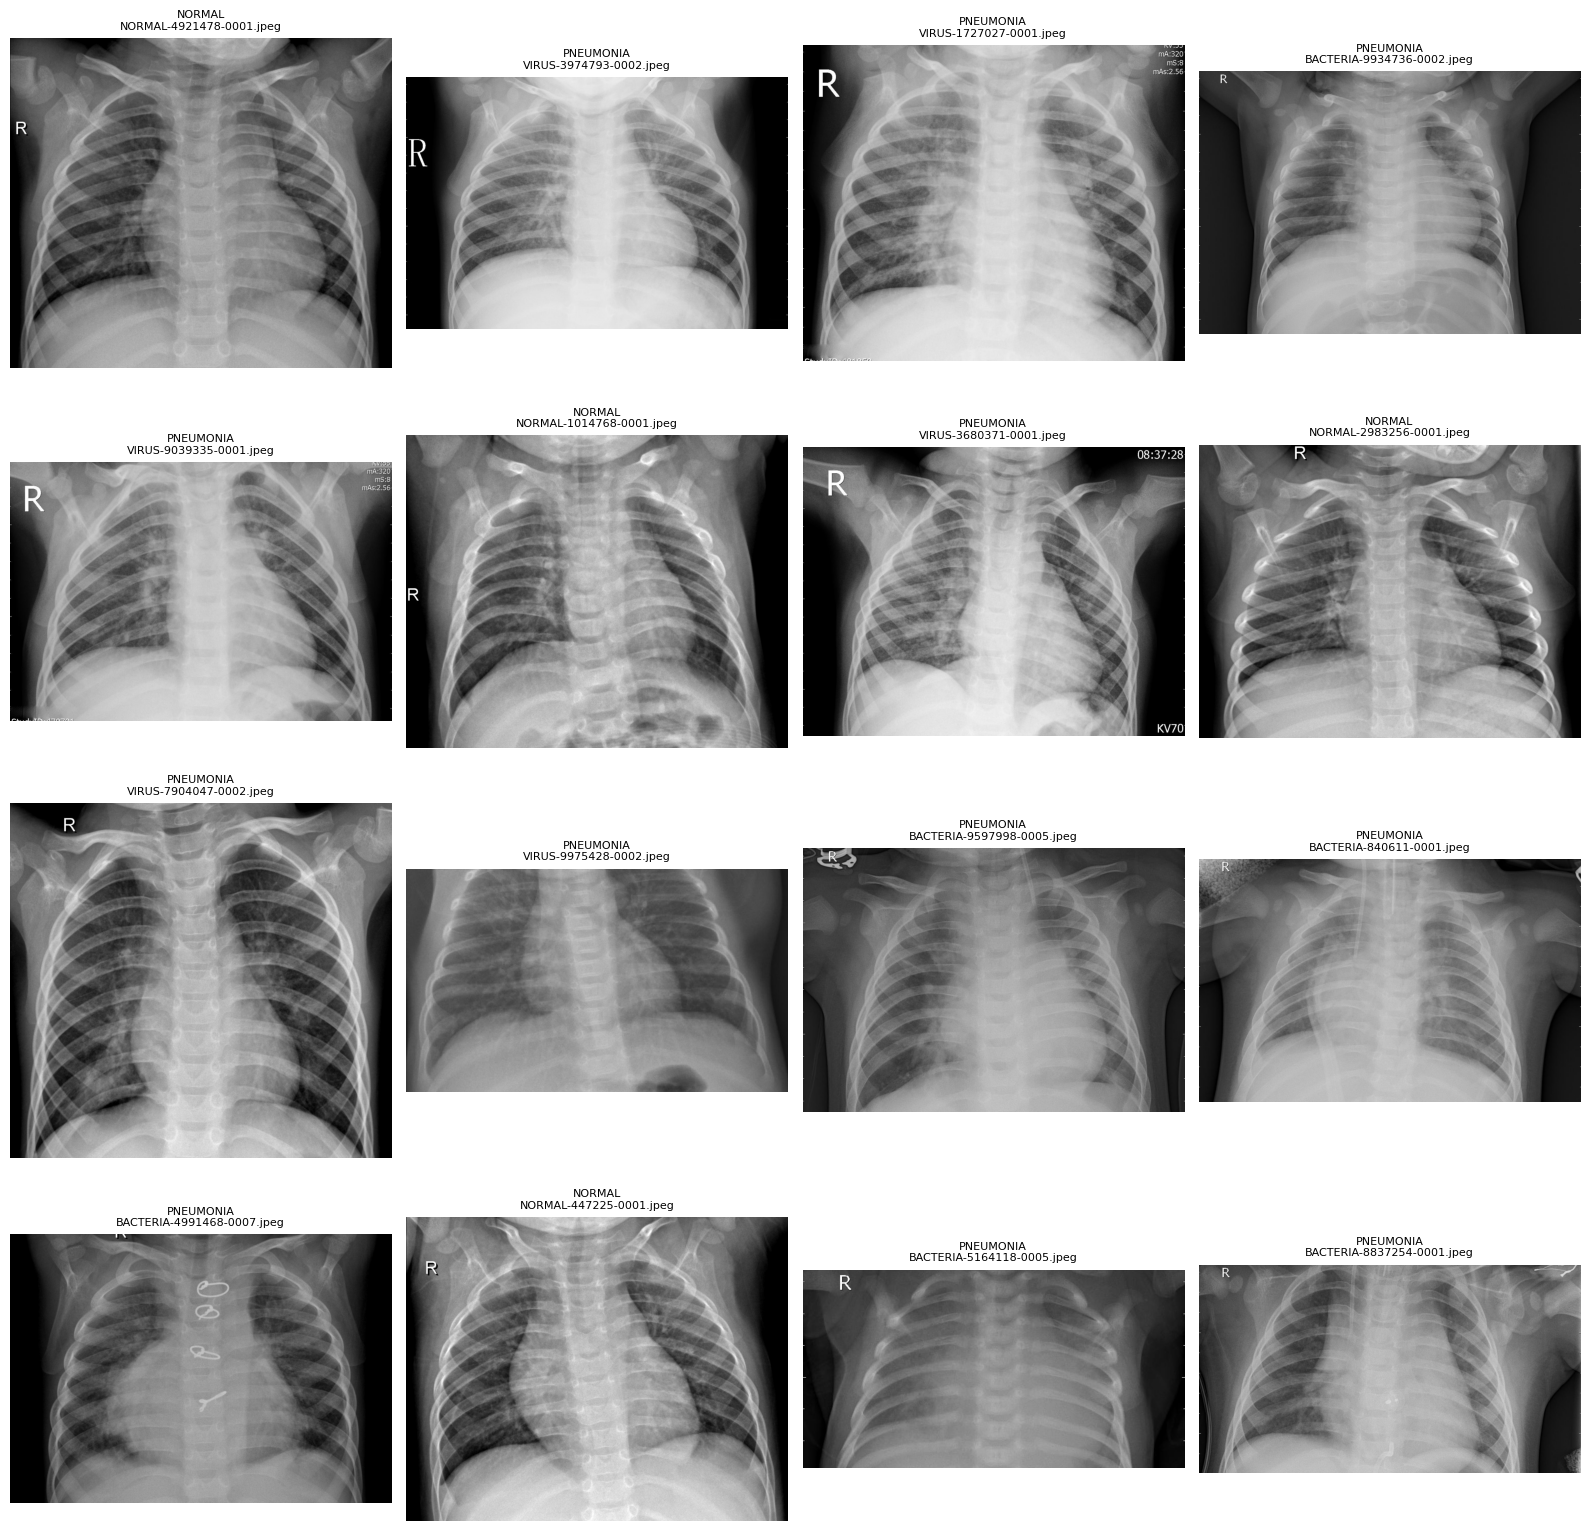

In [4]:
# 16枚の画像を4x4グリッドで表示
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for idx, img_path in enumerate(sample_paths):
    ax = axes[idx]
    try:
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
        # 親フォルダ名をクラス名相当として表示
        p = Path(img_path)
        ax.set_title(f"{p.parent.name}\n{p.name[:28]}", fontsize=8)
        ax.axis('off')
    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {e}", ha='center', va='center')
        ax.axis('off')

plt.tight_layout()
plt.show()

In [5]:
# サンプル画像のサイズ確認 (最初の5枚)
print("サンプル画像サイズ一覧:")
for img_path in sample_paths[:5]:
    try:
        with Image.open(img_path) as im:
            print(f"  {Path(img_path).name}: {im.size} (width x height)")
    except Exception as e:
        print(f"  {Path(img_path).name}: Error {e}")

サンプル画像サイズ一覧:
  NORMAL-4921478-0001.jpeg: (1562, 1352) (width x height)
  VIRUS-3974793-0002.jpeg: (1344, 888) (width x height)
  VIRUS-1727027-0001.jpeg: (1216, 1008) (width x height)
  BACTERIA-9934736-0002.jpeg: (1288, 888) (width x height)
  VIRUS-9039335-0001.jpeg: (1296, 880) (width x height)


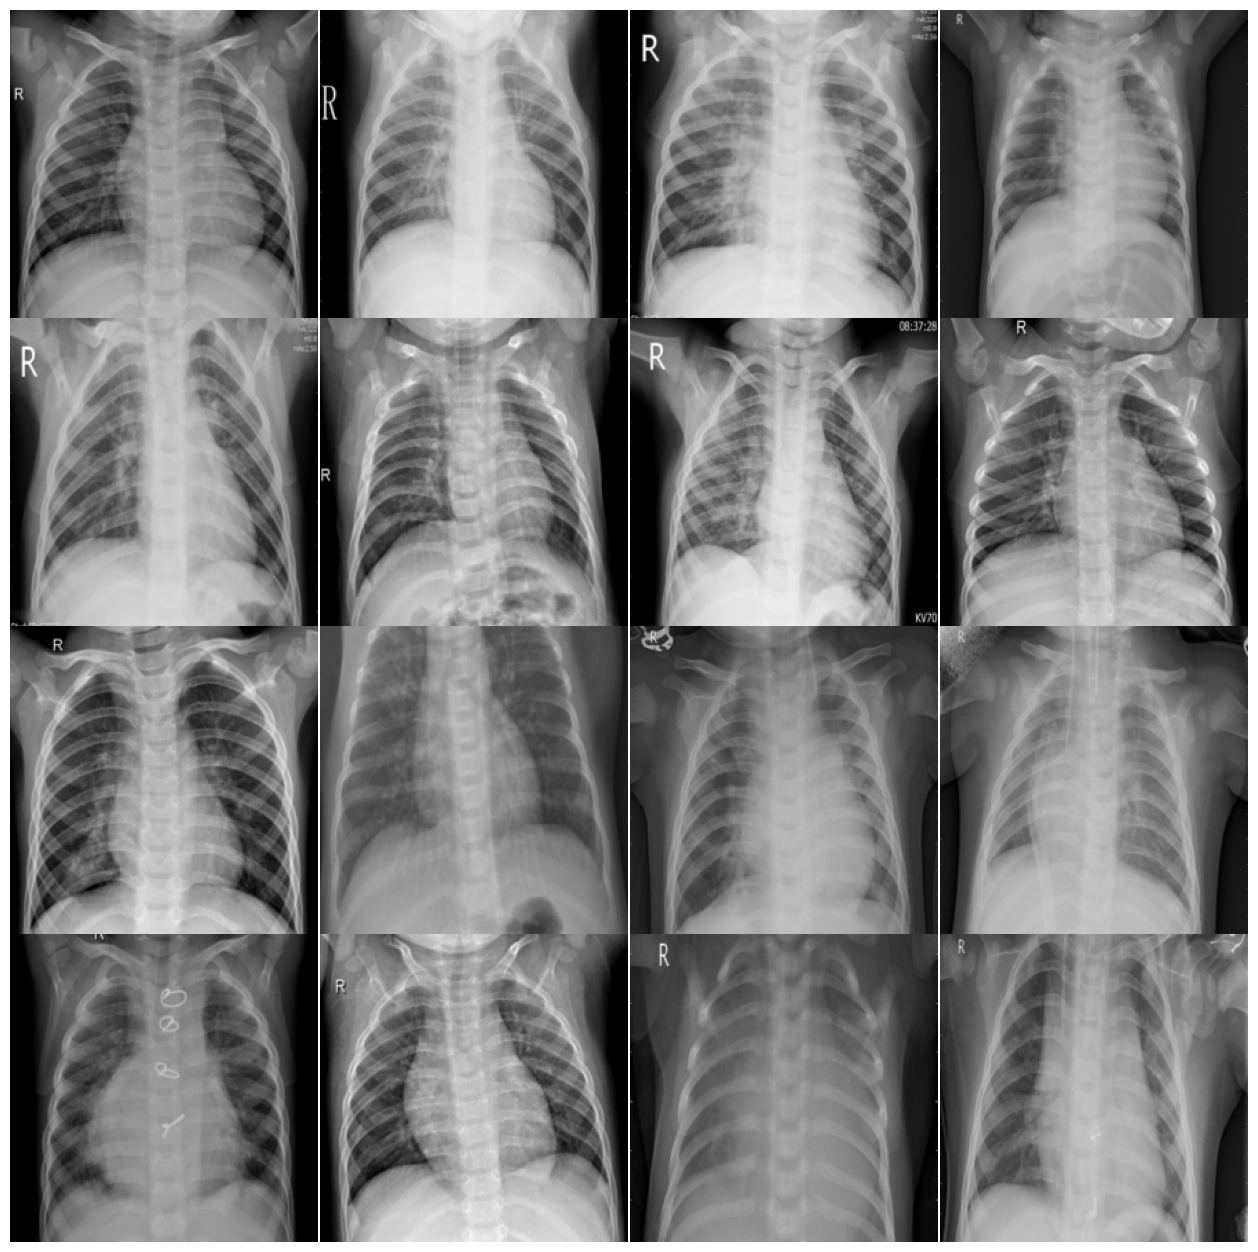


リサイズ後のサイズ: 224x224
表示画像数: 16


In [6]:
from torchvision import transforms

# リサイズ用のtransform（拡散モデルと同じ224x224）
resize_transform = transforms.Compose([
    transforms.Resize((224, 224)),
])

# 16枚の画像を224x224にリサイズして4x4グリッドで表示
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for idx, img_path in enumerate(sample_paths):
    try:
        img = Image.open(img_path).convert('RGB')
        img_resized = resize_transform(img)
        axes[idx].imshow(img_resized)
        
        # ファイル名とクラス名を表示
        axes[idx].axis('off')
    except Exception as e:
        axes[idx].text(0.5, 0.5, f"Error: {e}", ha='center', va='center')
        axes[idx].axis('off')

# 画像間の余白を0に設定
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

print(f"\nリサイズ後のサイズ: 224x224")
print(f"表示画像数: {len(sample_paths)}")